# Cross-task ablation: Hendel ↔ repetition

Score output→input heads independently on Hendel (1000 prompts) and on the repetition task (50 prompts), then test whether ablating each task's top-10% heads affects ICL accuracy on **both** tasks.

**Cross-task design.** For each evaluation task, we test four ablation states:
- Unablated (baseline)
- Top 10% heads from THIS task ablated (within-task)
- Top 10% heads from the OTHER task ablated (cross-task)
- Random 10% heads ablated (control)

If the within-task and cross-task ablations cause similar drops, the mechanism is shared. If they differ, the mechanisms are partially distinct.

**Two evaluation scopes.** First the orig condition only (clean test of head transfer). Then a full sweep over manipulation conditions for both tasks.

In [1]:
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, pickle, random, seaborn as sns
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from math import sqrt
from transformer_lens import HookedTransformer
from configs import *
from utils import *
%matplotlib inline

sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads

with open('../../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)

rng = random.Random(42)
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-25 11:54:36.599178: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.10it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


## Build Hendel pools and donor mapping (for full sweep later)

In [2]:
W_E = model.W_E.detach()

hendel_input_pool = []; hendel_input_tokids = []
hendel_output_pool = []; hendel_output_tokids = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts']:
        for inp, out in pdata['demo_pairs']:
            hendel_input_pool.append(inp)
            hendel_input_tokids.append(model.to_tokens(' ' + inp, prepend_bos=False)[0, 0].item())
            hendel_output_pool.append(out)
            hendel_output_tokids.append(model.to_tokens(' ' + out, prepend_bos=False)[0, 0].item())
hendel_mean_input_embed  = W_E[hendel_input_tokids].mean(dim=0)
hendel_mean_output_embed = W_E[hendel_output_tokids].mean(dim=0)

task_list = sorted(all_splits.keys())
donor_task = {t: task_list[(i + len(task_list) // 2) % len(task_list)]
              for i, t in enumerate(task_list)}

print(f'Hendel input pool: {len(hendel_input_pool)}, output pool: {len(hendel_output_pool)}')

Hendel input pool: 10000, output pool: 10000


## Build repetition prompts

In [3]:
CONSONANTS = 'bdfghjklmnprstvwz'
VOWELS = 'aeiou'

def make_nonsense(length=5, _rng=None):
    _rng = _rng or rng
    pattern = [CONSONANTS, VOWELS] * (length // 2 + 1)
    return ''.join(_rng.choice(p) for p in pattern[:length])

_rng_rep = random.Random(123)
N_REP_PROMPTS = 50
DEMOS_PER_PROMPT = 10
rep_prompts_data = []
for _ in range(N_REP_PROMPTS):
    inputs = [make_nonsense(_rng=_rng_rep) for _ in range(DEMOS_PER_PROMPT)]
    outputs = [i + i for i in inputs]
    qi = make_nonsense(_rng=_rng_rep)
    while qi in inputs:
        qi = make_nonsense(_rng=_rng_rep)
    qo = qi + qi
    prompt = build_icl_prompt(list(zip(inputs, outputs)), qi)
    rep_prompts_data.append({
        'demo_pairs': list(zip(inputs, outputs)),
        'query_input': qi,
        'query_output': qo,
        'prompt': prompt,
    })

# Repetition pools
rep_input_pool = []; rep_input_tokids = []
rep_output_pool = []; rep_output_tokids = []
for pdata in rep_prompts_data:
    for inp, out in pdata['demo_pairs']:
        rep_input_pool.append(inp)
        rep_input_tokids.append(model.to_tokens(' ' + inp, prepend_bos=False)[0, 0].item())
        rep_output_pool.append(out)
        rep_output_tokids.append(model.to_tokens(' ' + out, prepend_bos=False)[0, 0].item())
rep_mean_input_embed  = W_E[rep_input_tokids].mean(dim=0)
rep_mean_output_embed = W_E[rep_output_tokids].mean(dim=0)

print(f'Repetition prompts: {len(rep_prompts_data)}')
print(f'Example: {rep_prompts_data[0]["query_input"]} -> {rep_prompts_data[0]["query_output"]}')

Repetition prompts: 50
Example: wutiz -> wutizwutiz


## Score heads on Hendel (all 50 prompts/task = 1000 total)

In [4]:
def score_heads_on_prompts(prompts_data, desc='Scoring'):
    """Score output→input heads with baseline subtraction. Returns oi_score [n_layers, n_heads]."""
    num_sum  = np.zeros((n_layers, n_heads), dtype=np.float64)
    base_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    cnt = 0
    
    for pdata in tqdm(prompts_data, desc=desc):
        demos = pdata['demo_pairs']
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
        
        all_inputs = set(); all_outputs = set()
        for d in per_demo:
            for p in d.get('input_positions', []):  all_inputs.add(p)
            for p in d.get('output_positions', []): all_outputs.add(p)
        
        num_mask = torch.zeros(seq_len, seq_len)
        for d in per_demo:
            for op in d.get('output_positions', []):
                for ip in d.get('input_positions', []):
                    num_mask[op, ip] = 1.0
        
        base_mask = torch.zeros(seq_len, seq_len)
        ins_list = sorted(all_inputs)
        for q in range(seq_len):
            if q in all_outputs: continue
            for ik in ins_list:
                if ik <= q: base_mask[q, ik] = 1.0
        
        n_num  = int(num_mask.sum().item())
        n_base = int(base_mask.sum().item())
        if n_num == 0 or n_base == 0: continue
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        for L in range(n_layers):
            patt = cache['pattern', L][0].cpu().float()
            num_sum[L, :]  += (patt * num_mask).sum(dim=(1, 2)).numpy() / n_num
            base_sum[L, :] += (patt * base_mask).sum(dim=(1, 2)).numpy() / n_base
        cnt += 1
        del cache
        torch.cuda.empty_cache()
    
    num_avg  = num_sum  / max(cnt, 1)
    base_avg = base_sum / max(cnt, 1)
    return num_avg - base_avg, num_avg, base_avg, cnt

all_hendel_prompts = [pdata for splits in all_splits.values() for pdata in splits['icl_prompts']]
oi_score_hendel, oi_num_hendel, oi_base_hendel, n_hendel_scored = score_heads_on_prompts(
    all_hendel_prompts, desc='Score on Hendel')

flat_hendel = sorted([(L, h, oi_score_hendel[L, h]) for L in range(n_layers) for h in range(n_heads)],
                     key=lambda x: -x[2])
top10pct_n = max(1, int(0.10 * n_layers * n_heads))
H_hendel = [(L, h) for L, h, s in flat_hendel[:top10pct_n]]

print(f'\nScored {n_hendel_scored} Hendel prompts')
print(f'Hendel top 10:')
for L, h, s in flat_hendel[:10]:
    print(f'  L{L:2d}H{h:2d}: {s:+.4f}')

Score on Hendel: 100%|██████████| 1000/1000 [01:59<00:00,  8.34it/s]


Scored 1000 Hendel prompts
Hendel top 10:
  L 5H 3: +0.1925
  L10H10: +0.1554
  L 4H14: +0.1369
  L13H13: +0.1250
  L 7H 7: +0.1177
  L 7H18: +0.1059
  L 8H 8: +0.1017
  L 1H16: +0.0901
  L13H12: +0.0893
  L12H 1: +0.0890


## Score heads on repetition (50 prompts)

In [5]:
oi_score_rep, oi_num_rep, oi_base_rep, n_rep_scored = score_heads_on_prompts(
    rep_prompts_data, desc='Score on repetition')

flat_rep = sorted([(L, h, oi_score_rep[L, h]) for L in range(n_layers) for h in range(n_heads)],
                  key=lambda x: -x[2])
H_rep = [(L, h) for L, h, s in flat_rep[:top10pct_n]]

print(f'\nScored {n_rep_scored} repetition prompts')
print(f'Repetition top 10:')
for L, h, s in flat_rep[:10]:
    print(f'  L{L:2d}H{h:2d}: {s:+.4f}')

Score on repetition: 100%|██████████| 50/50 [00:07<00:00,  6.63it/s]


Scored 50 repetition prompts
Repetition top 10:
  L 4H14: +0.2689
  L 8H 8: +0.2381
  L13H14: +0.2050
  L14H22: +0.1638
  L18H11: +0.1428
  L16H 3: +0.1399
  L 5H 8: +0.1262
  L18H10: +0.1232
  L23H10: +0.1223
  L13H13: +0.1203


## Compare H_hendel vs H_rep

Top 67 heads each (10% of 672)
Overlap:           23 (34.3%)
Only in Hendel:    44
Only in repetition:44


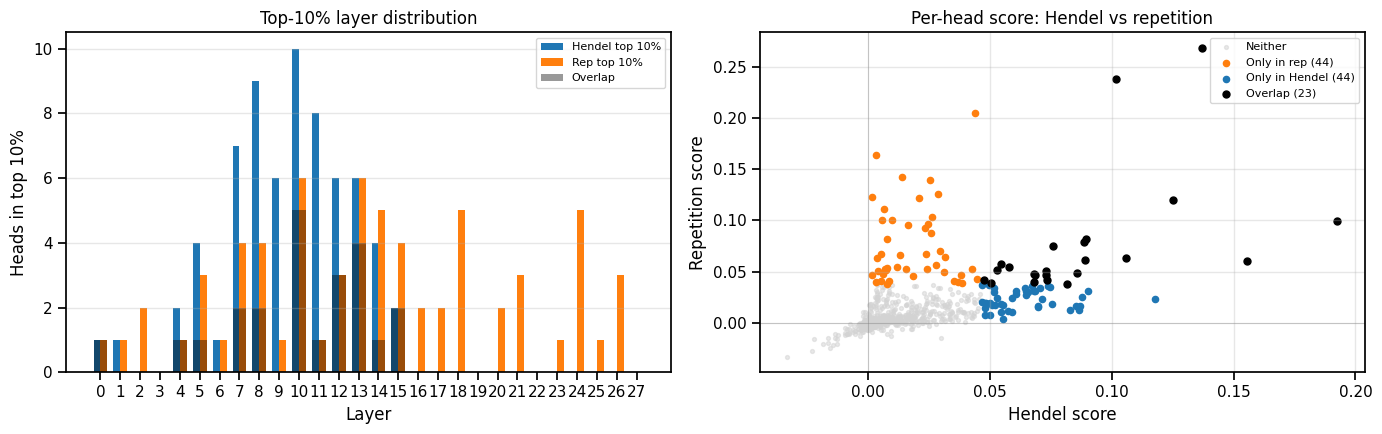

In [6]:
set_hendel = set(H_hendel); set_rep = set(H_rep)
overlap   = set_hendel & set_rep
only_hen  = set_hendel - set_rep
only_rep  = set_rep - set_hendel

print(f'Top {top10pct_n} heads each (10% of {n_layers * n_heads})')
print(f'Overlap:           {len(overlap)} ({100*len(overlap)/top10pct_n:.1f}%)')
print(f'Only in Hendel:    {len(only_hen)}')
print(f'Only in repetition:{len(only_rep)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

def layer_hist(head_set):
    counts = np.zeros(n_layers, dtype=int)
    for L, _ in head_set: counts[L] += 1
    return counts

x = np.arange(n_layers); w = 0.35
h_hendel = layer_hist(set_hendel); h_rep = layer_hist(set_rep); h_over = layer_hist(overlap)
axes[0].bar(x - w/2, h_hendel, w, label='Hendel top 10%', color='tab:blue')
axes[0].bar(x + w/2, h_rep,    w, label='Rep top 10%',    color='tab:orange')
axes[0].bar(x - w/2, h_over,   w, color='black', alpha=0.4, label='Overlap')
axes[0].bar(x + w/2, h_over,   w, color='black', alpha=0.4)
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Heads in top 10%')
axes[0].set_title('Top-10% layer distribution')
axes[0].set_xticks(x); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

ax = axes[1]
all_x = oi_score_hendel.flatten()
all_y = oi_score_rep.flatten()
in_over = np.zeros((n_layers, n_heads), dtype=bool)
in_only_h = np.zeros((n_layers, n_heads), dtype=bool)
in_only_r = np.zeros((n_layers, n_heads), dtype=bool)
for L, h in overlap: in_over[L, h] = True
for L, h in only_hen: in_only_h[L, h] = True
for L, h in only_rep: in_only_r[L, h] = True
neither = ~(in_over | in_only_h | in_only_r)
ax.scatter(all_x[neither.flatten()], all_y[neither.flatten()], s=8, c='lightgray', alpha=0.5, label='Neither')
ax.scatter(all_x[in_only_r.flatten()], all_y[in_only_r.flatten()], s=20, c='tab:orange', label=f'Only in rep ({len(only_rep)})')
ax.scatter(all_x[in_only_h.flatten()], all_y[in_only_h.flatten()], s=20, c='tab:blue', label=f'Only in Hendel ({len(only_hen)})')
ax.scatter(all_x[in_over.flatten()], all_y[in_over.flatten()], s=25, c='black', label=f'Overlap ({len(overlap)})')
ax.set_xlabel('Hendel score'); ax.set_ylabel('Repetition score')
ax.set_title('Per-head score: Hendel vs repetition')
ax.axhline(0, color='gray', alpha=0.5, lw=0.5); ax.axvline(0, color='gray', alpha=0.5, lw=0.5)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Build ablation hook sets

In [7]:
def heads_by_layer_from(head_list):
    d = defaultdict(list)
    for L, h in head_list: d[L].append(h)
    return d

def make_ablation_hooks(heads_by_layer):
    fwd_hooks = []
    for L, h_list in heads_by_layer.items():
        def hook(z, hook, _h_list=h_list):
            for h in _h_list: z[0, :, h, :] = 0
            return z
        fwd_hooks.append((f'blocks.{L}.attn.hook_z', hook))
    return fwd_hooks

def make_embed_hook(positions, replacement_vec):
    def hook_fn(emb, hook):
        for p in positions: emb[:, p, :] = replacement_vec.to(emb.dtype)
        return emb
    return hook_fn

def answer_rank(model, logits, answer):
    ans_tok = model.to_tokens(' ' + answer, prepend_bos=False)[0, 0].item()
    return int((logits > logits[ans_tok]).sum().item())

set_hendel_heads  = list(H_hendel)
set_rep_heads     = list(H_rep)
overlap_heads     = sorted(set(H_hendel) & set(H_rep))
only_hendel_heads = sorted(set(H_hendel) - set(H_rep))
only_rep_heads    = sorted(set(H_rep)    - set(H_hendel))

all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]
exclude_for_random = set(H_hendel) | set(H_rep)
candidates = [p for p in all_pairs if p not in exclude_for_random]

_rngs = [random.Random(s) for s in range(5)]
rand_for_hendel  = _rngs[0].sample(candidates, len(set_hendel_heads))
rand_for_rep     = _rngs[1].sample(candidates, len(set_rep_heads))
rand_for_overlap = _rngs[2].sample(candidates, len(overlap_heads))    if overlap_heads     else []
rand_for_only_h  = _rngs[3].sample(candidates, len(only_hendel_heads)) if only_hendel_heads else []
rand_for_only_r  = _rngs[4].sample(candidates, len(only_rep_heads))    if only_rep_heads    else []

ablation_hook_sets = {
    'unablated':           [],
    'all_hendel':          make_ablation_hooks(heads_by_layer_from(set_hendel_heads)),
    'rand_for_hendel':     make_ablation_hooks(heads_by_layer_from(rand_for_hendel)),
    'all_rep':             make_ablation_hooks(heads_by_layer_from(set_rep_heads)),
    'rand_for_rep':        make_ablation_hooks(heads_by_layer_from(rand_for_rep)),
    'overlap':             make_ablation_hooks(heads_by_layer_from(overlap_heads)),
    'rand_for_overlap':    make_ablation_hooks(heads_by_layer_from(rand_for_overlap)),
    'only_hendel':         make_ablation_hooks(heads_by_layer_from(only_hendel_heads)),
    'rand_for_only_h':     make_ablation_hooks(heads_by_layer_from(rand_for_only_h)),
    'only_rep':            make_ablation_hooks(heads_by_layer_from(only_rep_heads)),
    'rand_for_only_r':     make_ablation_hooks(heads_by_layer_from(rand_for_only_r)),
}

ABL_KEYS = [
    'unablated',
    'all_hendel',          'rand_for_hendel',
    'all_rep',             'rand_for_rep',
    'overlap',             'rand_for_overlap',
    'only_hendel',         'rand_for_only_h',
    'only_rep',            'rand_for_only_r',
]

# Disambiguated labels: each random control includes its pair name so labels are unique
ab_label = {
    'unablated':         'Unablated',
    'all_hendel':        f'All Hendel ({len(set_hendel_heads)})',
    'rand_for_hendel':   f'→ Random match ({len(set_hendel_heads)})',
    'all_rep':           f'All rep ({len(set_rep_heads)})',
    'rand_for_rep':      f'→ Random match ({len(set_rep_heads)})',
    'overlap':           f'Overlap ({len(overlap_heads)})',
    'rand_for_overlap':  f'→ Random match ({len(overlap_heads)})',
    'only_hendel':       f'Uniq Hendel ({len(only_hendel_heads)})',
    'rand_for_only_h':   f'→ Random match ({len(only_hendel_heads)}, uH)',
    'only_rep':          f'Uniq rep ({len(only_rep_heads)})',
    'rand_for_only_r':   f'→ Random match ({len(only_rep_heads)}, uR)',
}

ab_color_by_key = {
    'unablated':        '#222222',
    'all_hendel':       '#cc3333',
    'rand_for_hendel':  '#f4b4b4',
    'all_rep':          '#cc7700',
    'rand_for_rep':     '#f4d39e',
    'overlap':          '#1f77b4',
    'rand_for_overlap': '#aac8e0',
    'only_hendel':      '#7a1a1a',
    'rand_for_only_h':  '#d9a3a3',
    'only_rep':         '#5a3500',
    'rand_for_only_r':  '#cdb89e',
}

ab_palette = {ab_label[k]: c for k, c in ab_color_by_key.items()}
ab_order = [ab_label[k] for k in ABL_KEYS]

print(f'Built ablation hook sets ({len(ablation_hook_sets)} total):')
print(f'  All Hendel:    {len(set_hendel_heads)} heads')
print(f'  All rep:       {len(set_rep_heads)} heads')
print(f'  Overlap:       {len(overlap_heads)} heads')
print(f'  Uniq Hendel:   {len(only_hendel_heads)} heads')
print(f'  Uniq rep:      {len(only_rep_heads)} heads')
print(f'  All controls drawn from heads NOT in (H_hendel ∪ H_rep), independent random samples per pair.')

Built ablation hook sets (11 total):
  All Hendel:    67 heads
  All rep:       67 heads
  Overlap:       23 heads
  Uniq Hendel:   44 heads
  Uniq rep:      44 heads
  All controls drawn from heads NOT in (H_hendel ∪ H_rep), independent random samples per pair.


# Orig-only evaluation

Test ICL accuracy and answer rank on the orig prompt only, under all four ablation states, for both tasks.

## Eval on Hendel orig (1000 prompts)

In [8]:
hendel_orig_correct = {ab: [] for ab in ABL_KEYS}
hendel_orig_rank    = {ab: [] for ab in ABL_KEYS}
hendel_orig_task    = []

hendel_jobs = [(t, p_idx, pdata)
               for t, splits in all_splits.items()
               for p_idx, pdata in enumerate(splits['icl_prompts'])]

for t, p_idx, pdata in tqdm(hendel_jobs, desc='Hendel orig eval'):
    ans = pdata.get('query_output')
    if ans is None: continue
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    last = tokens.shape[1] - 1
    
    for ab_key, ab_hooks in ablation_hook_sets.items():
        with torch.no_grad():
            if ab_hooks:
                logits = model.run_with_hooks(tokens, fwd_hooks=ab_hooks)[0, last]
            else:
                logits = model(tokens)[0, last]
        hendel_orig_correct[ab_key].append(int(check_correct(model, logits, ans)))
        hendel_orig_rank[ab_key].append(answer_rank(model, logits, ans))
    hendel_orig_task.append(t)
    torch.cuda.empty_cache()

for ab in ABL_KEYS:
    hendel_orig_correct[ab] = np.array(hendel_orig_correct[ab])
    hendel_orig_rank[ab]    = np.array(hendel_orig_rank[ab])
n_hendel_orig = len(hendel_orig_correct['unablated'])
print(f'\nTotal Hendel prompts: {n_hendel_orig}')
for ab in ABL_KEYS:
    print(f'  {ab_label[ab]:<22} acc={hendel_orig_correct[ab].mean():.3f}  rank={hendel_orig_rank[ab].mean():.2f}')

Hendel orig eval: 100%|██████████| 1000/1000 [11:45<00:00,  1.42it/s]


Total Hendel prompts: 1000
  Unablated              acc=0.838  rank=2.00
  All Hendel (67)        acc=0.747  rank=2.76
  → Random match (67)    acc=0.795  rank=4.59
  All rep (67)           acc=0.609  rank=14.98
  → Random match (67)    acc=0.726  rank=24.23
  Overlap (23)           acc=0.811  rank=1.58
  → Random match (23)    acc=0.825  rank=3.27
  Uniq Hendel (44)       acc=0.808  rank=3.59
  → Random match (44, uH) acc=0.828  rank=3.55
  Uniq rep (44)          acc=0.689  rank=6.46
  → Random match (44, uR) acc=0.804  rank=2.50


## Eval on repetition orig (50 prompts)

In [9]:
@torch.no_grad()
def check_correct_multitoken(model, tokens, expected, max_new_tokens=6, hooks=None):
    """Greedy decode with hooks; whitespace-normalize and check prefix match."""
    def _normalize(s): return ''.join(s.split()).lower()
    target = _normalize(expected)
    generated = []
    cur = tokens.clone()
    for _ in range(max_new_tokens):
        if hooks:
            logits = model.run_with_hooks(cur, fwd_hooks=hooks)[0, -1]
        else:
            logits = model(cur)[0, -1]
        nt = logits.argmax().item()
        generated.append(nt)
        cur = torch.cat([cur, torch.tensor([[nt]], device=cur.device)], dim=1)
        decoded = _normalize(model.tokenizer.decode(generated))
        if decoded and not target.startswith(decoded): return 0
        if decoded.startswith(target): return 1
    decoded = _normalize(model.tokenizer.decode(generated))
    return int(decoded.startswith(target))

rep_orig_correct = {ab: [] for ab in ABL_KEYS}
rep_orig_rank    = {ab: [] for ab in ABL_KEYS}

for pdata in tqdm(rep_prompts_data, desc='Repetition orig eval'):
    ans = pdata['query_output']
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    last = tokens.shape[1] - 1
    
    for ab_key, ab_hooks in ablation_hook_sets.items():
        rep_orig_correct[ab_key].append(check_correct_multitoken(model, tokens, ans, hooks=ab_hooks if ab_hooks else None))
        with torch.no_grad():
            if ab_hooks:
                logits = model.run_with_hooks(tokens, fwd_hooks=ab_hooks)[0, last]
            else:
                logits = model(tokens)[0, last]
        rep_orig_rank[ab_key].append(answer_rank(model, logits, ans))
    torch.cuda.empty_cache()

for ab in ABL_KEYS:
    rep_orig_correct[ab] = np.array(rep_orig_correct[ab])
    rep_orig_rank[ab]    = np.array(rep_orig_rank[ab])
n_rep_orig = len(rep_orig_correct['unablated'])
print(f'\nTotal repetition prompts: {n_rep_orig}')
for ab in ABL_KEYS:
    print(f'  {ab_label[ab]:<22} acc={rep_orig_correct[ab].mean():.3f}  rank={rep_orig_rank[ab].mean():.2f}')

Repetition orig eval: 100%|██████████| 50/50 [03:04<00:00,  3.70s/it]


Total repetition prompts: 50
  Unablated              acc=0.940  rank=0.04
  All Hendel (67)        acc=0.780  rank=0.04
  → Random match (67)    acc=0.900  rank=0.04
  All rep (67)           acc=0.000  rank=358.12
  → Random match (67)    acc=0.860  rank=0.64
  Overlap (23)           acc=0.760  rank=0.28
  → Random match (23)    acc=0.940  rank=0.04
  Uniq Hendel (44)       acc=0.880  rank=0.04
  → Random match (44, uH) acc=0.980  rank=0.04
  Uniq rep (44)          acc=0.000  rank=30.62
  → Random match (44, uR) acc=0.940  rank=0.04


## Combined orig-only plot

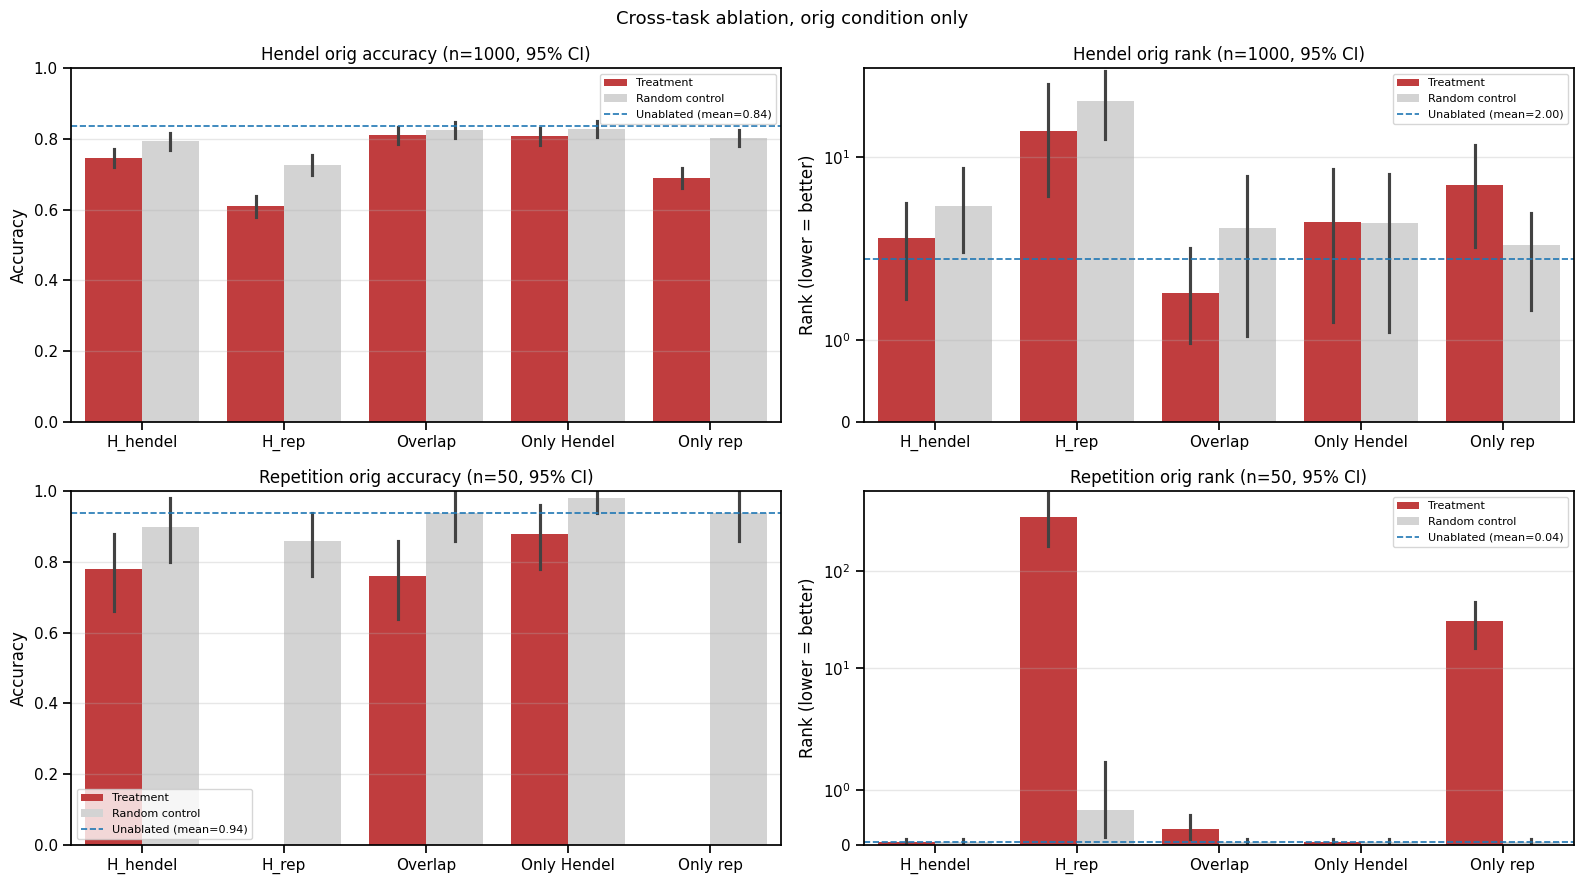

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

PAIRS = [
    ('all_hendel',  'rand_for_hendel',  'H_hendel'),
    ('all_rep',     'rand_for_rep',     'H_rep'),
    ('overlap',     'rand_for_overlap', 'Overlap'),
    ('only_hendel', 'rand_for_only_h',  'Only Hendel'),
    ('only_rep',    'rand_for_only_r',  'Only rep'),
]
group_order = [name for _, _, name in PAIRS]
hue_order = ['Treatment', 'Random control']
hue_palette = {'Treatment': 'tab:red', 'Random control': 'lightgray'}

def build_df(data_dict):
    rows = []
    for treat_key, ctrl_key, group_name in PAIRS:
        for v in data_dict[treat_key]:
            rows.append({'Group': group_name, 'Kind': 'Treatment', 'value': v})
        for v in data_dict[ctrl_key]:
            rows.append({'Group': group_name, 'Kind': 'Random control', 'value': v})
    return pd.DataFrame(rows)

def grouped_bar_paired(ax, data_dict, n, title, ylabel, ylim=None, log=False):
    df = build_df(data_dict)
    sns.barplot(data=df, x='Group', y='value', hue='Kind',
                order=group_order, hue_order=hue_order, palette=hue_palette,
                errorbar=('ci', 95), linewidth=0, ax=ax)
    
    unab_mean = data_dict['unablated'].mean()
    ax.axhline(unab_mean, color='tab:blue', linestyle='--', linewidth=1.2,
               label=f'Unablated (mean={unab_mean:.2f})')
    ax.legend(fontsize=8, loc='best')
    
    ax.set_xlabel(''); ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(*ylim)
    if log: ax.set_yscale('symlog')
    ax.set_title(f'{title} (n={n}, 95% CI)')
    ax.grid(True, alpha=0.3, axis='y')

grouped_bar_paired(axes[0, 0], hendel_orig_correct, n_hendel_orig,
                   'Hendel orig accuracy', 'Accuracy', ylim=(0, 1.0))
grouped_bar_paired(axes[0, 1], hendel_orig_rank, n_hendel_orig,
                   'Hendel orig rank', 'Rank (lower = better)', log=True)
grouped_bar_paired(axes[1, 0], rep_orig_correct, n_rep_orig,
                   'Repetition orig accuracy', 'Accuracy', ylim=(0, 1.0))
grouped_bar_paired(axes[1, 1], rep_orig_rank, n_rep_orig,
                   'Repetition orig rank', 'Rank (lower = better)', log=True)

fig.suptitle('Cross-task ablation, orig condition only', fontsize=13)
plt.tight_layout(); plt.show()

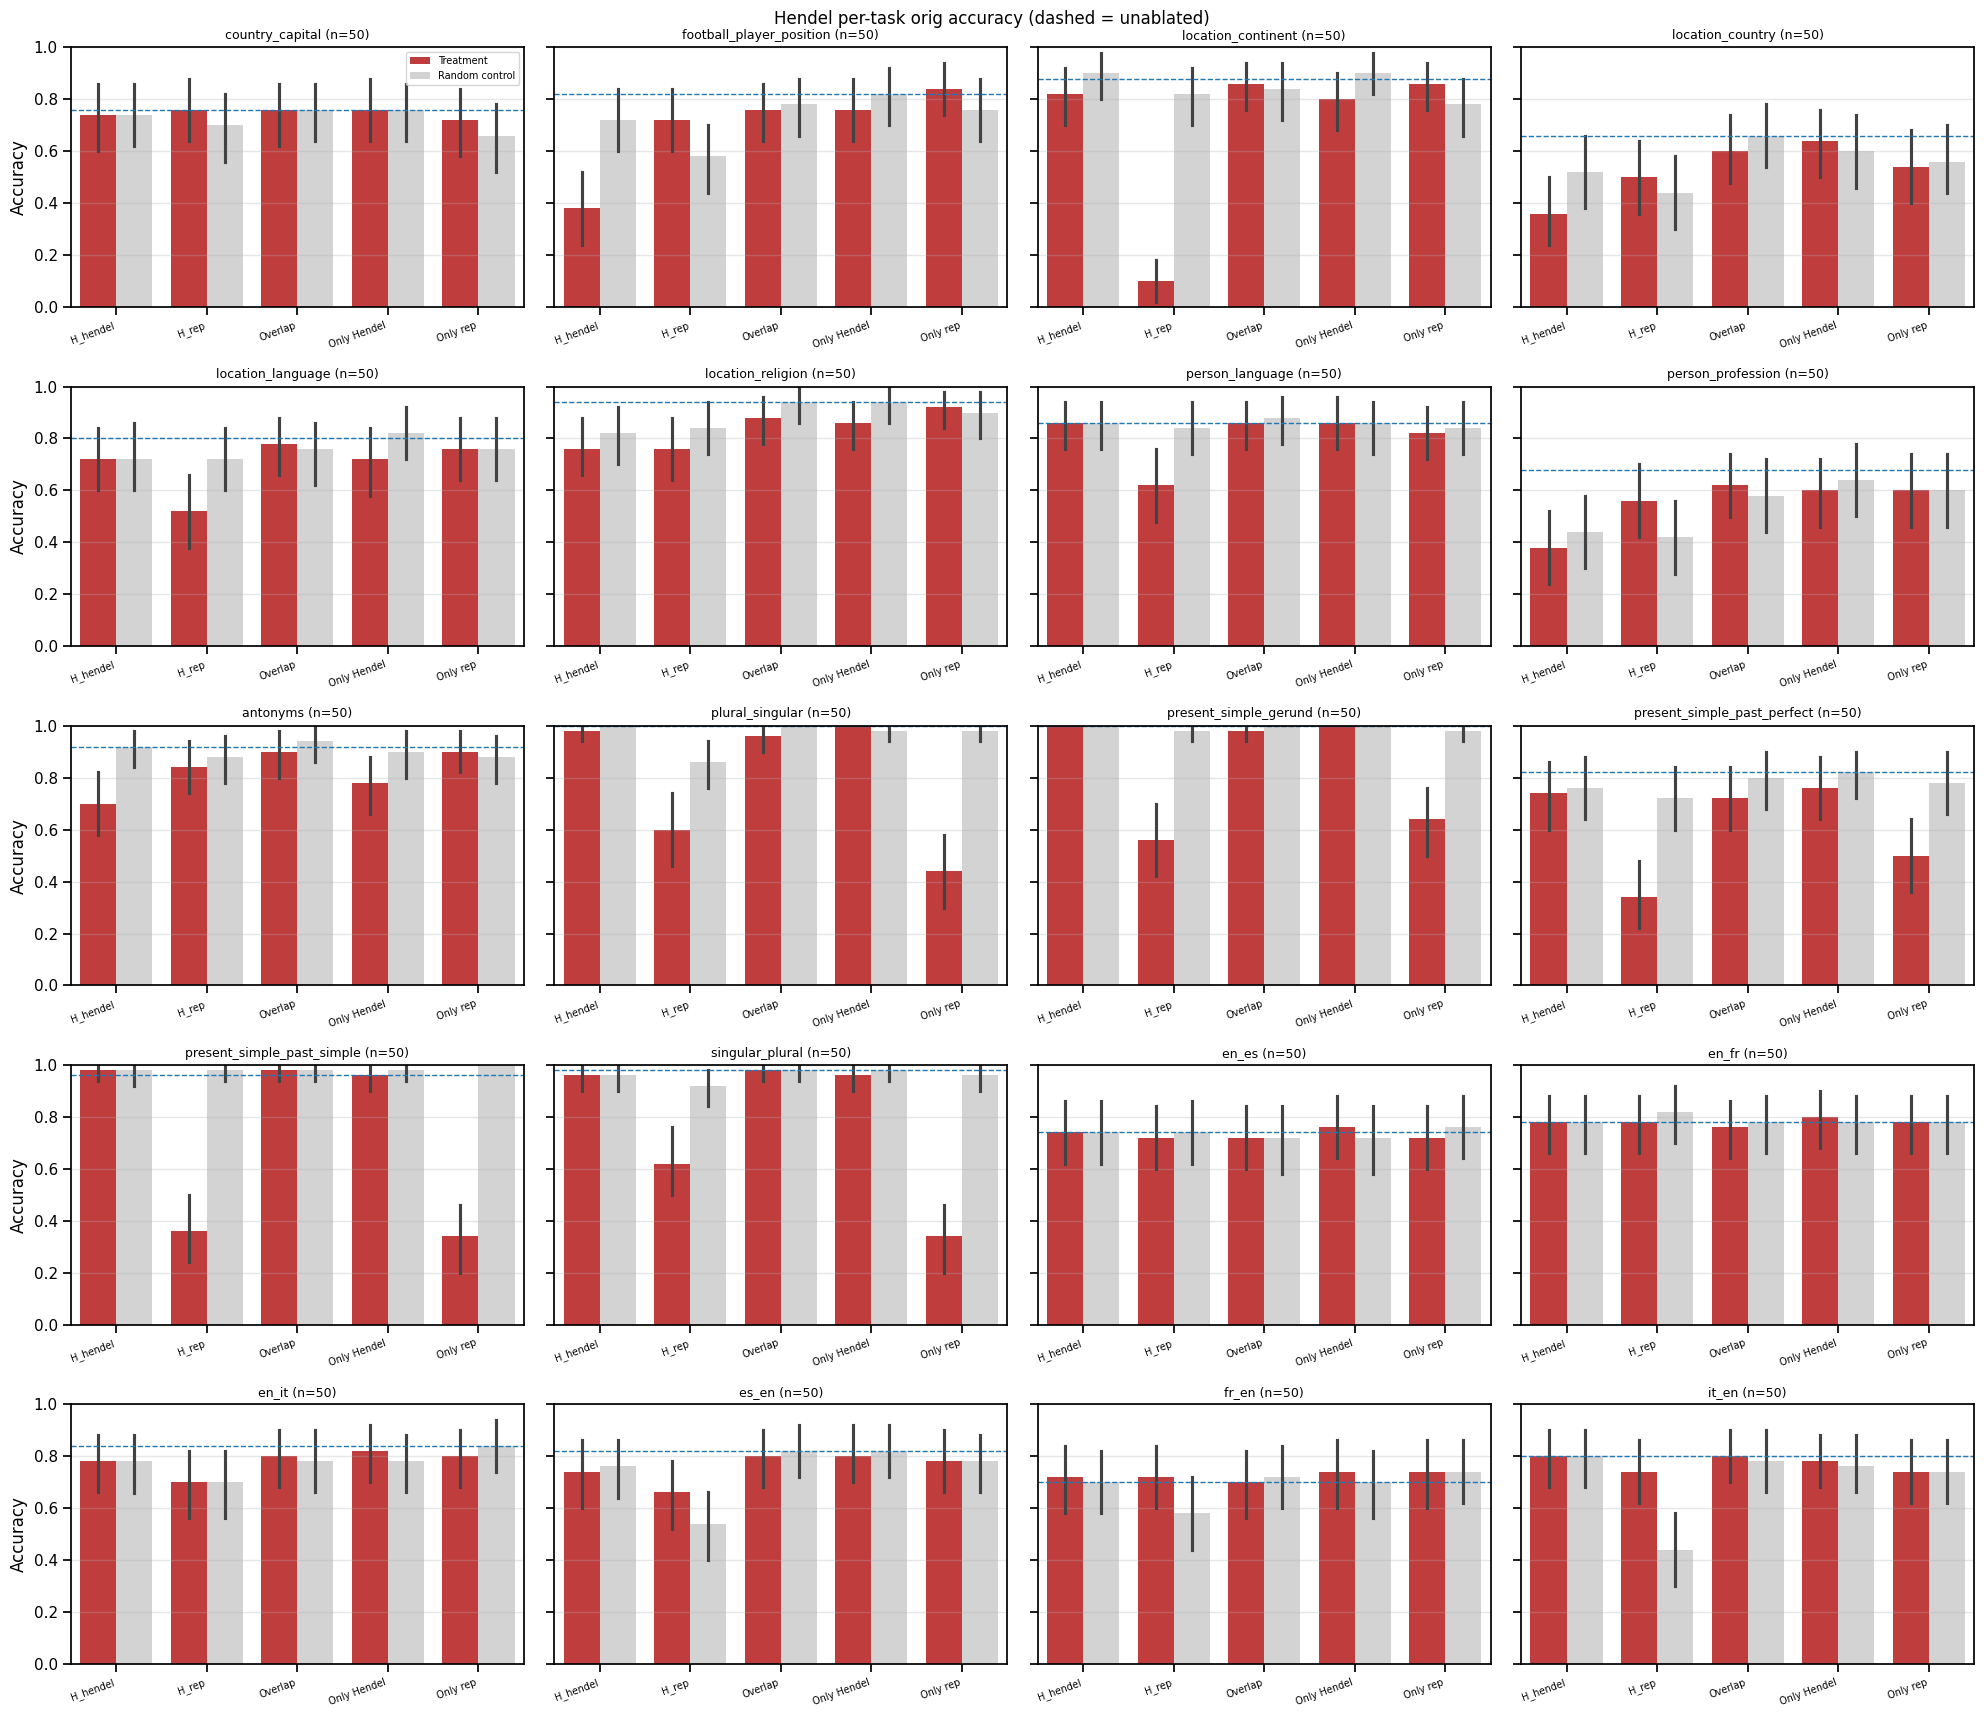

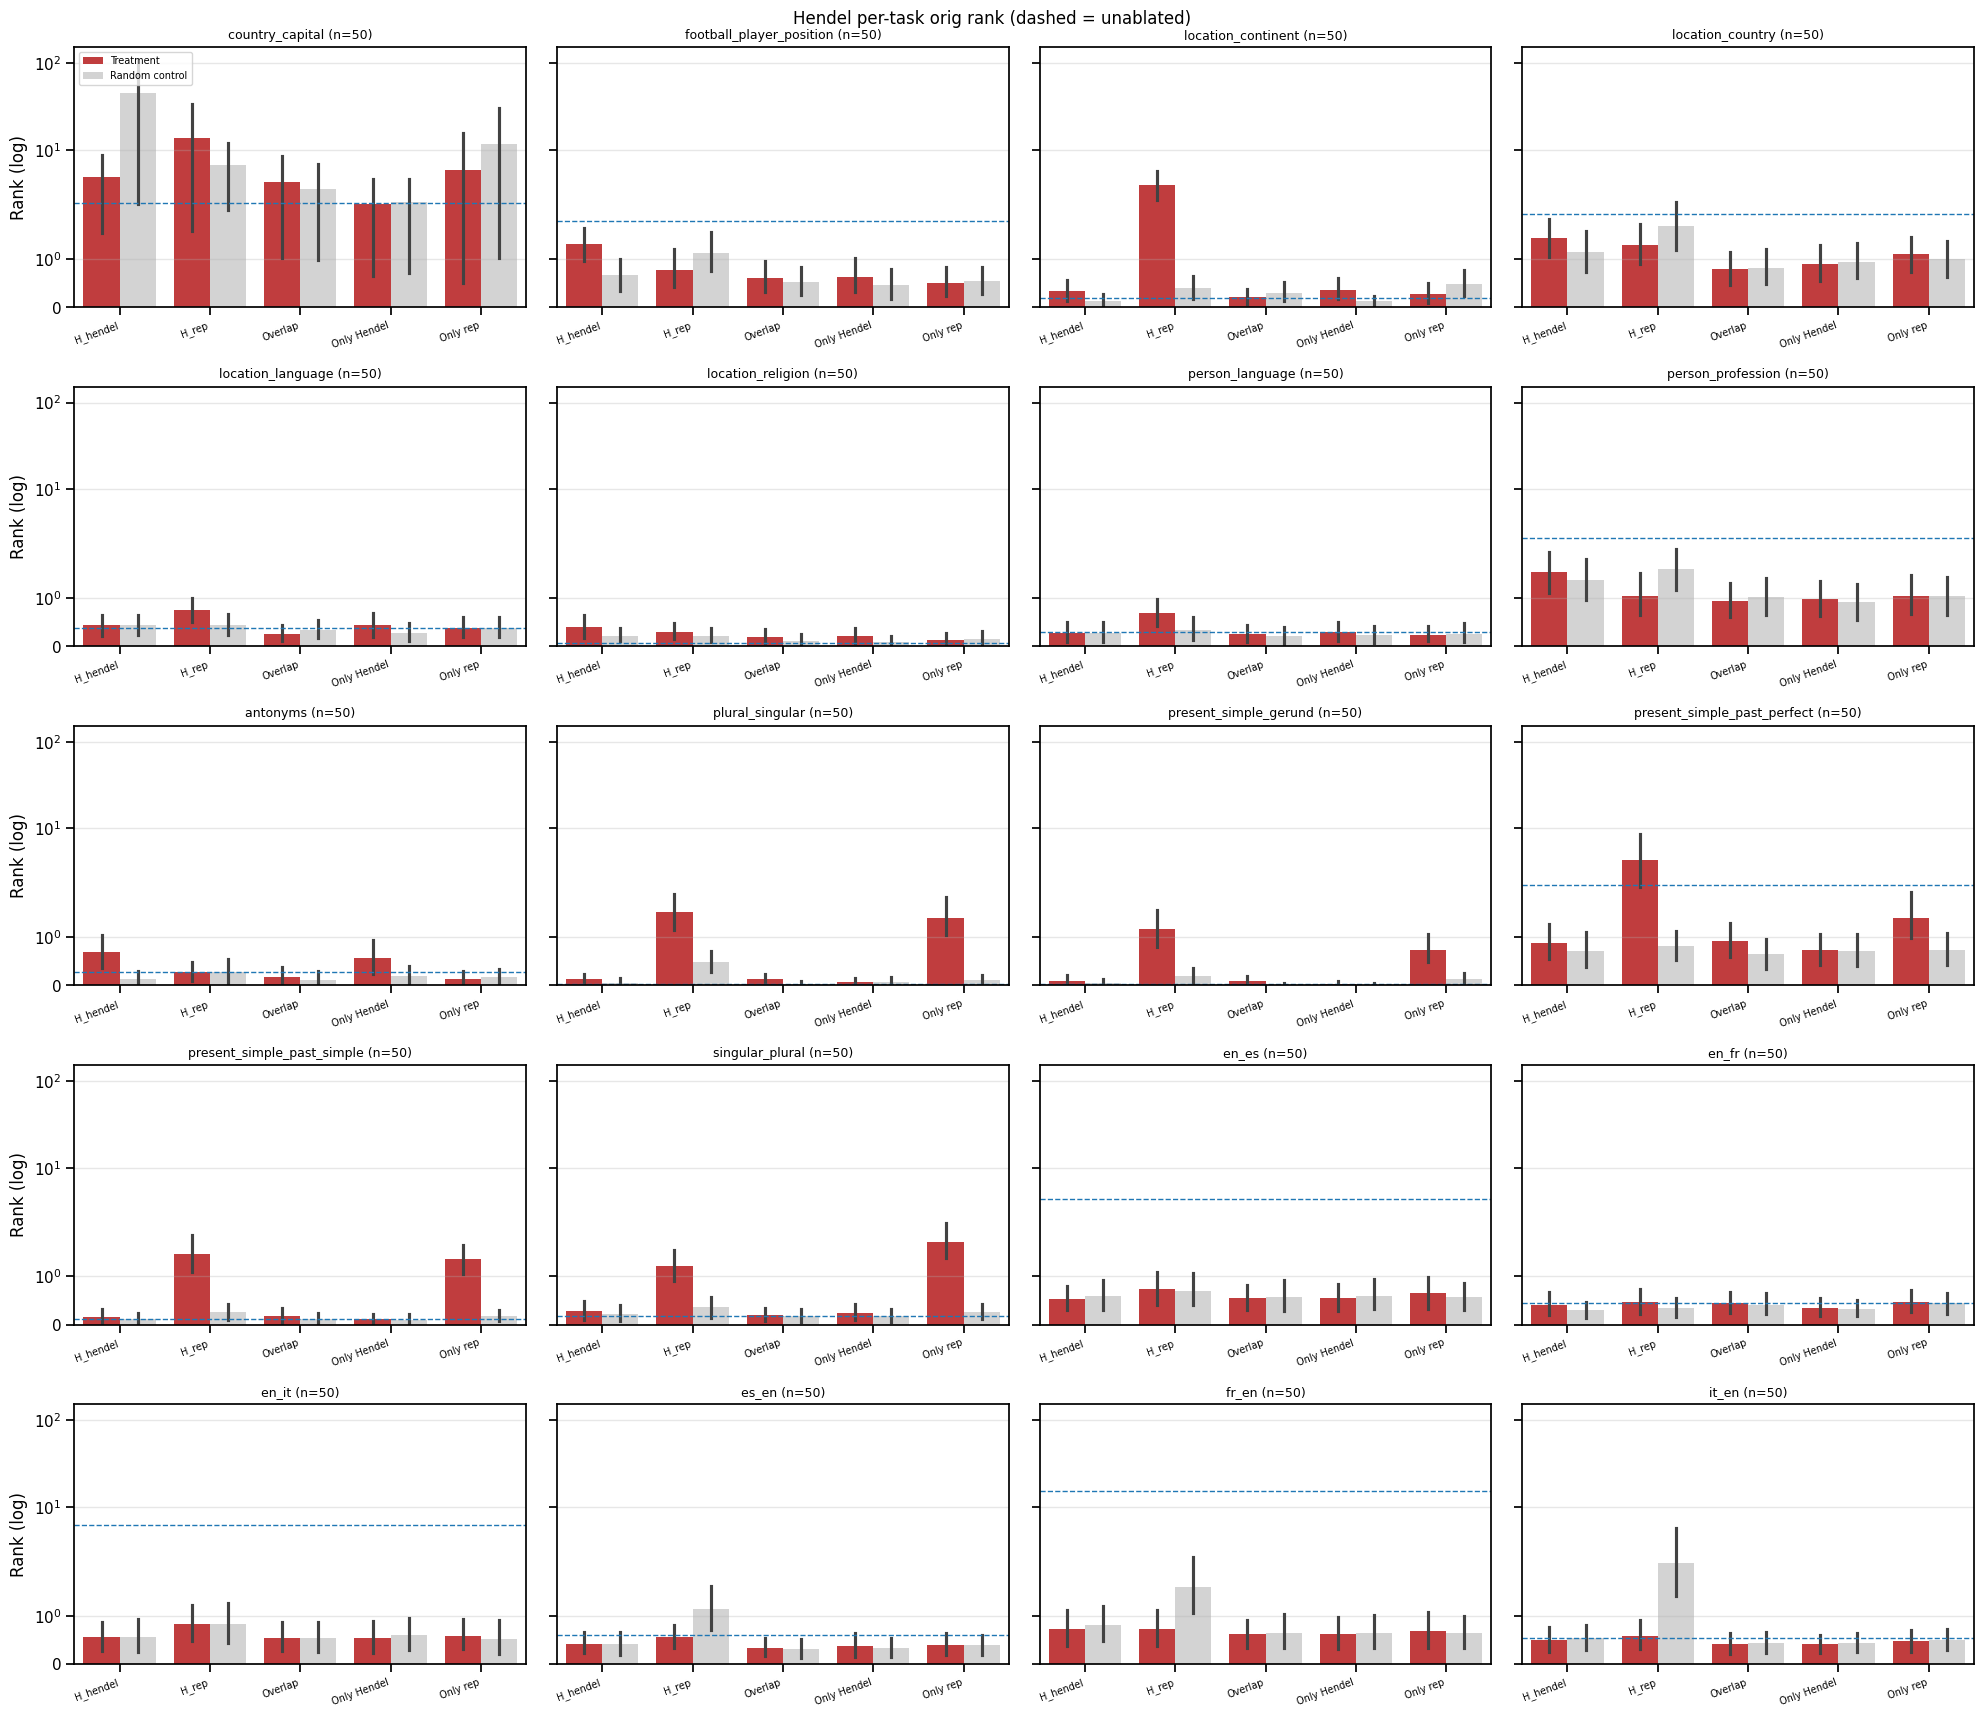

In [18]:
task_list_sorted = sorted(set(hendel_orig_task))
n_cols = 4
n_rows = int(np.ceil(len(task_list_sorted) / n_cols))

def build_per_task_df(data_dict, value_name):
    rows = []
    for i in range(n_hendel_orig):
        t = hendel_orig_task[i]
        for treat_key, ctrl_key, group_name in PAIRS:
            rows.append({'Task': t, 'Group': group_name, 'Kind': 'Treatment',
                         value_name: data_dict[treat_key][i]})
            rows.append({'Task': t, 'Group': group_name, 'Kind': 'Random control',
                         value_name: data_dict[ctrl_key][i]})
    return pd.DataFrame(rows)

df_acc  = build_per_task_df(hendel_orig_correct, 'value')
df_rank = build_per_task_df(hendel_orig_rank,    'value')

# Accuracy figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows), sharey=True)
axes = axes.flatten()
for ax, t in zip(axes, task_list_sorted):
    sub = df_acc[df_acc['Task'] == t]
    sns.barplot(data=sub, x='Group', y='value', hue='Kind',
                order=group_order, hue_order=hue_order, palette=hue_palette,
                errorbar=('ci', 95), linewidth=0, ax=ax, legend=(ax is axes[0]))
    mask = np.array([tt == t for tt in hendel_orig_task])
    unab_mean = hendel_orig_correct['unablated'][mask].mean()
    ax.axhline(unab_mean, color='tab:blue', linestyle='--', linewidth=1.0)
    n_t = mask.sum()
    ax.set_title(f'{t.split("/")[-1]} (n={n_t})', fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel('')
    ax.set_ylabel('Accuracy' if ax in axes[::n_cols] else '')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=7)
axes[0].legend(fontsize=7, loc='upper right')
for ax in axes[len(task_list_sorted):]:
    ax.set_visible(False)
fig.suptitle('Hendel per-task orig accuracy (dashed = unablated)', fontsize=12)
plt.tight_layout(); plt.show()

# Rank figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows), sharey=True)
axes = axes.flatten()
for ax, t in zip(axes, task_list_sorted):
    sub = df_rank[df_rank['Task'] == t]
    sns.barplot(data=sub, x='Group', y='value', hue='Kind',
                order=group_order, hue_order=hue_order, palette=hue_palette,
                errorbar=('ci', 95), linewidth=0, ax=ax, legend=(ax is axes[0]))
    mask = np.array([tt == t for tt in hendel_orig_task])
    unab_mean = hendel_orig_rank['unablated'][mask].mean()
    ax.axhline(unab_mean, color='tab:blue', linestyle='--', linewidth=1.0)
    n_t = mask.sum()
    ax.set_title(f'{t.split("/")[-1]} (n={n_t})', fontsize=9)
    ax.set_yscale('symlog')
    ax.set_xlabel('')
    ax.set_ylabel('Rank (log)' if ax in axes[::n_cols] else '')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=7)
axes[0].legend(fontsize=7, loc='upper left')
for ax in axes[len(task_list_sorted):]:
    ax.set_visible(False)
fig.suptitle('Hendel per-task orig rank (dashed = unablated)', fontsize=12)
plt.tight_layout(); plt.show()

# Full sweep

Repeat under all manipulation conditions for both tasks. Each task has its own condition list (Hendel vs repetition use slightly different conditions). For each (task, condition, ablation) combination, compute accuracy and rank.

## Hendel full sweep

In [19]:
HENDEL_CONDS = ['orig', 'shuffled', 'wrong_task_inputs', 'random_from_input_pool',
                'mean_embed_inputs', 'star_inputs', 'query_only',
                'shuffled_outputs', 'wrong_task_outputs', 'random_from_output_pool',
                'mean_embed_outputs', 'star_outputs']

hendel_full_correct = {ab: {c: [] for c in HENDEL_CONDS} for ab in ABL_KEYS}
hendel_full_rank    = {ab: {c: [] for c in HENDEL_CONDS} for ab in ABL_KEYS}

for t, p_idx, pdata in tqdm(hendel_jobs, desc='Hendel full sweep'):
    demos = pdata['demo_pairs']
    qi = pdata['query_input']
    ans = pdata.get('query_output')
    if ans is None: continue
    
    inputs  = [i for i, _ in demos]
    outputs = [o for _, o in demos]
    inputs_shuffled  = inputs.copy();  rng.shuffle(inputs_shuffled)
    outputs_shuffled = outputs.copy(); rng.shuffle(outputs_shuffled)
    
    donor_pdata = all_splits[donor_task[t]]['icl_prompts'][p_idx % len(all_splits[donor_task[t]]['icl_prompts'])]
    inputs_wrong  = [i for i, _ in donor_pdata['demo_pairs']]
    outputs_wrong = [o for _, o in donor_pdata['demo_pairs']]
    if len(inputs_wrong) < len(demos):
        inputs_wrong  = (inputs_wrong  * ((len(demos) // len(inputs_wrong))  + 1))[:len(demos)]
        outputs_wrong = (outputs_wrong * ((len(demos) // len(outputs_wrong)) + 1))[:len(demos)]
    inputs_wrong = inputs_wrong[:len(demos)]; outputs_wrong = outputs_wrong[:len(demos)]
    
    inputs_random  = [rng.choice(hendel_input_pool)  for _ in inputs]
    outputs_random = [rng.choice(hendel_output_pool) for _ in outputs]
    
    prompts = {
        'orig':                     pdata['prompt'],
        'shuffled':                 build_icl_prompt(list(zip(inputs_shuffled, outputs)), qi),
        'wrong_task_inputs':        build_icl_prompt(list(zip(inputs_wrong, outputs)), qi),
        'random_from_input_pool':   build_icl_prompt(list(zip(inputs_random, outputs)), qi),
        'star_inputs':              build_icl_prompt([('*', o) for o in outputs], qi),
        'query_only':               f'{qi} \u2192',
        'shuffled_outputs':         build_icl_prompt(list(zip(inputs, outputs_shuffled)), qi),
        'wrong_task_outputs':       build_icl_prompt(list(zip(inputs, outputs_wrong)),    qi),
        'random_from_output_pool':  build_icl_prompt(list(zip(inputs, outputs_random)),   qi),
        'star_outputs':             build_icl_prompt([(i, '*') for i in inputs], qi),
    }
    tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
    lasts  = {k: v.shape[1] - 1 for k, v in tokens.items()}
    
    per_demo = find_per_demo_positions(model, prompts['orig'], demos)
    in_pos  = [p for d in per_demo for p in d.get('input_positions', [])]
    out_pos = [p for d in per_demo for p in d.get('output_positions', [])]
    
    for ab_key, ab_hooks in ablation_hook_sets.items():
        for c in HENDEL_CONDS:
            extra = []
            if c == 'mean_embed_inputs':
                extra = [('hook_embed', make_embed_hook(in_pos, hendel_mean_input_embed))]
                tgt_tokens = tokens['orig']; tgt_last = lasts['orig']
            elif c == 'mean_embed_outputs':
                extra = [('hook_embed', make_embed_hook(out_pos, hendel_mean_output_embed))]
                tgt_tokens = tokens['orig']; tgt_last = lasts['orig']
            else:
                tgt_tokens = tokens[c]; tgt_last = lasts[c]
            combined = list(ab_hooks) + extra
            with torch.no_grad():
                if combined:
                    logits = model.run_with_hooks(tgt_tokens, fwd_hooks=combined)[0, tgt_last]
                else:
                    logits = model(tgt_tokens)[0, tgt_last]
            hendel_full_correct[ab_key][c].append(int(check_correct(model, logits, ans)))
            hendel_full_rank[ab_key][c].append(answer_rank(model, logits, ans))
    torch.cuda.empty_cache()

for ab in ABL_KEYS:
    for c in HENDEL_CONDS:
        hendel_full_correct[ab][c] = np.array(hendel_full_correct[ab][c])
        hendel_full_rank[ab][c]    = np.array(hendel_full_rank[ab][c])
n_hendel_full = len(hendel_full_correct['unablated']['orig'])
print(f'\nHendel full sweep: n={n_hendel_full}')

Hendel full sweep:   0%|          | 0/1000 [00:03<?, ?it/s]


KeyboardInterrupt: 

## Repetition full sweep

In [20]:
REP_CONDS = ['orig', 'shuffled_inputs', 'random_inputs', 'mean_embed_inputs',
             'star_inputs', 'shuffled_outputs', 'random_outputs',
             'mean_embed_outputs', 'star_outputs', 'query_only']

rep_full_correct = {ab: {c: [] for c in REP_CONDS} for ab in ABL_KEYS}
rep_full_rank    = {ab: {c: [] for c in REP_CONDS} for ab in ABL_KEYS}

for pdata in tqdm(rep_prompts_data, desc='Rep full sweep'):
    demos = pdata['demo_pairs']; qi = pdata['query_input']; ans = pdata['query_output']
    inputs  = [i for i, _ in demos]; outputs = [o for _, o in demos]
    inputs_shuffled  = inputs.copy();  rng.shuffle(inputs_shuffled)
    outputs_shuffled = outputs.copy(); rng.shuffle(outputs_shuffled)
    inputs_random    = [rng.choice(rep_input_pool)  for _ in inputs]
    outputs_random   = [rng.choice(rep_output_pool) for _ in outputs]
    
    prompts = {
        'orig':              pdata['prompt'],
        'shuffled_inputs':   build_icl_prompt(list(zip(inputs_shuffled, outputs)), qi),
        'random_inputs':     build_icl_prompt(list(zip(inputs_random, outputs)), qi),
        'star_inputs':       build_icl_prompt([('*', o) for o in outputs], qi),
        'query_only':        f'{qi} \u2192',
        'shuffled_outputs':  build_icl_prompt(list(zip(inputs, outputs_shuffled)), qi),
        'random_outputs':    build_icl_prompt(list(zip(inputs, outputs_random)),   qi),
        'star_outputs':      build_icl_prompt([(i, '*') for i in inputs], qi),
    }
    tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
    lasts  = {k: v.shape[1] - 1 for k, v in tokens.items()}
    
    per_demo = find_per_demo_positions(model, prompts['orig'], demos)
    in_pos  = [p for d in per_demo for p in d.get('input_positions', [])]
    out_pos = [p for d in per_demo for p in d.get('output_positions', [])]
    
    for ab_key, ab_hooks in ablation_hook_sets.items():
        for c in REP_CONDS:
            extra = []
            if c == 'mean_embed_inputs':
                extra = [('hook_embed', make_embed_hook(in_pos, rep_mean_input_embed))]
                tgt_tokens = tokens['orig']; tgt_last = lasts['orig']
            elif c == 'mean_embed_outputs':
                extra = [('hook_embed', make_embed_hook(out_pos, rep_mean_output_embed))]
                tgt_tokens = tokens['orig']; tgt_last = lasts['orig']
            else:
                tgt_tokens = tokens[c]; tgt_last = lasts[c]
            combined = list(ab_hooks) + extra
            # Accuracy via multi-token greedy decode (repetition needs whitespace handling)
            rep_full_correct[ab_key][c].append(
                check_correct_multitoken(model, tgt_tokens, ans, hooks=combined if combined else None))
            with torch.no_grad():
                if combined:
                    logits = model.run_with_hooks(tgt_tokens, fwd_hooks=combined)[0, tgt_last]
                else:
                    logits = model(tgt_tokens)[0, tgt_last]
            rep_full_rank[ab_key][c].append(answer_rank(model, logits, ans))
    torch.cuda.empty_cache()

for ab in ABL_KEYS:
    for c in REP_CONDS:
        rep_full_correct[ab][c] = np.array(rep_full_correct[ab][c])
        rep_full_rank[ab][c]    = np.array(rep_full_rank[ab][c])
n_rep_full = len(rep_full_correct['unablated']['orig'])
print(f'\nRepetition full sweep: n={n_rep_full}')

Rep full sweep: 100%|██████████| 50/50 [21:35<00:00, 25.91s/it]


Repetition full sweep: n=50


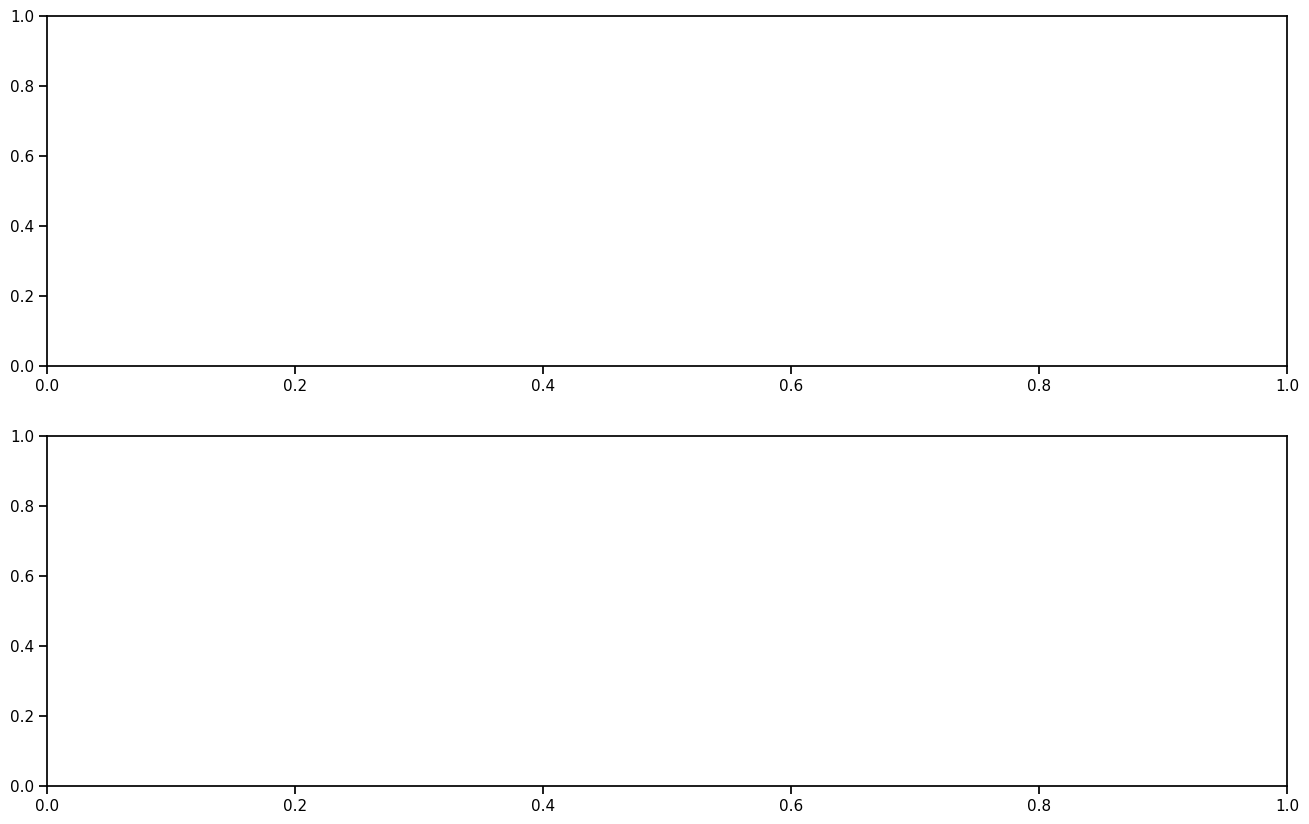

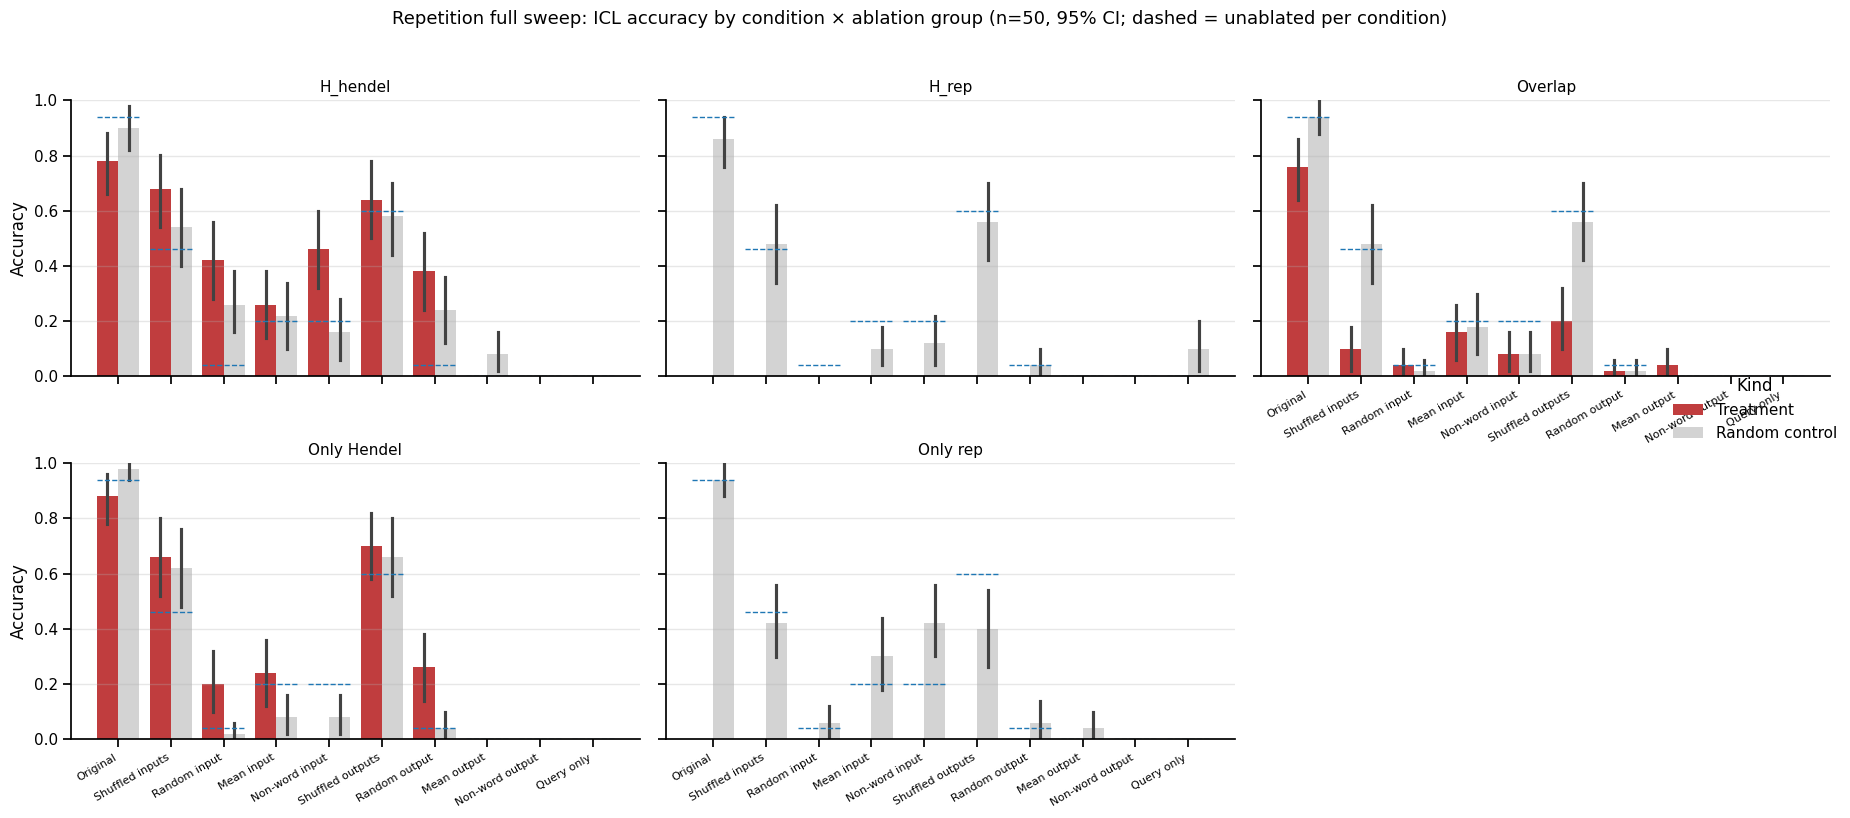

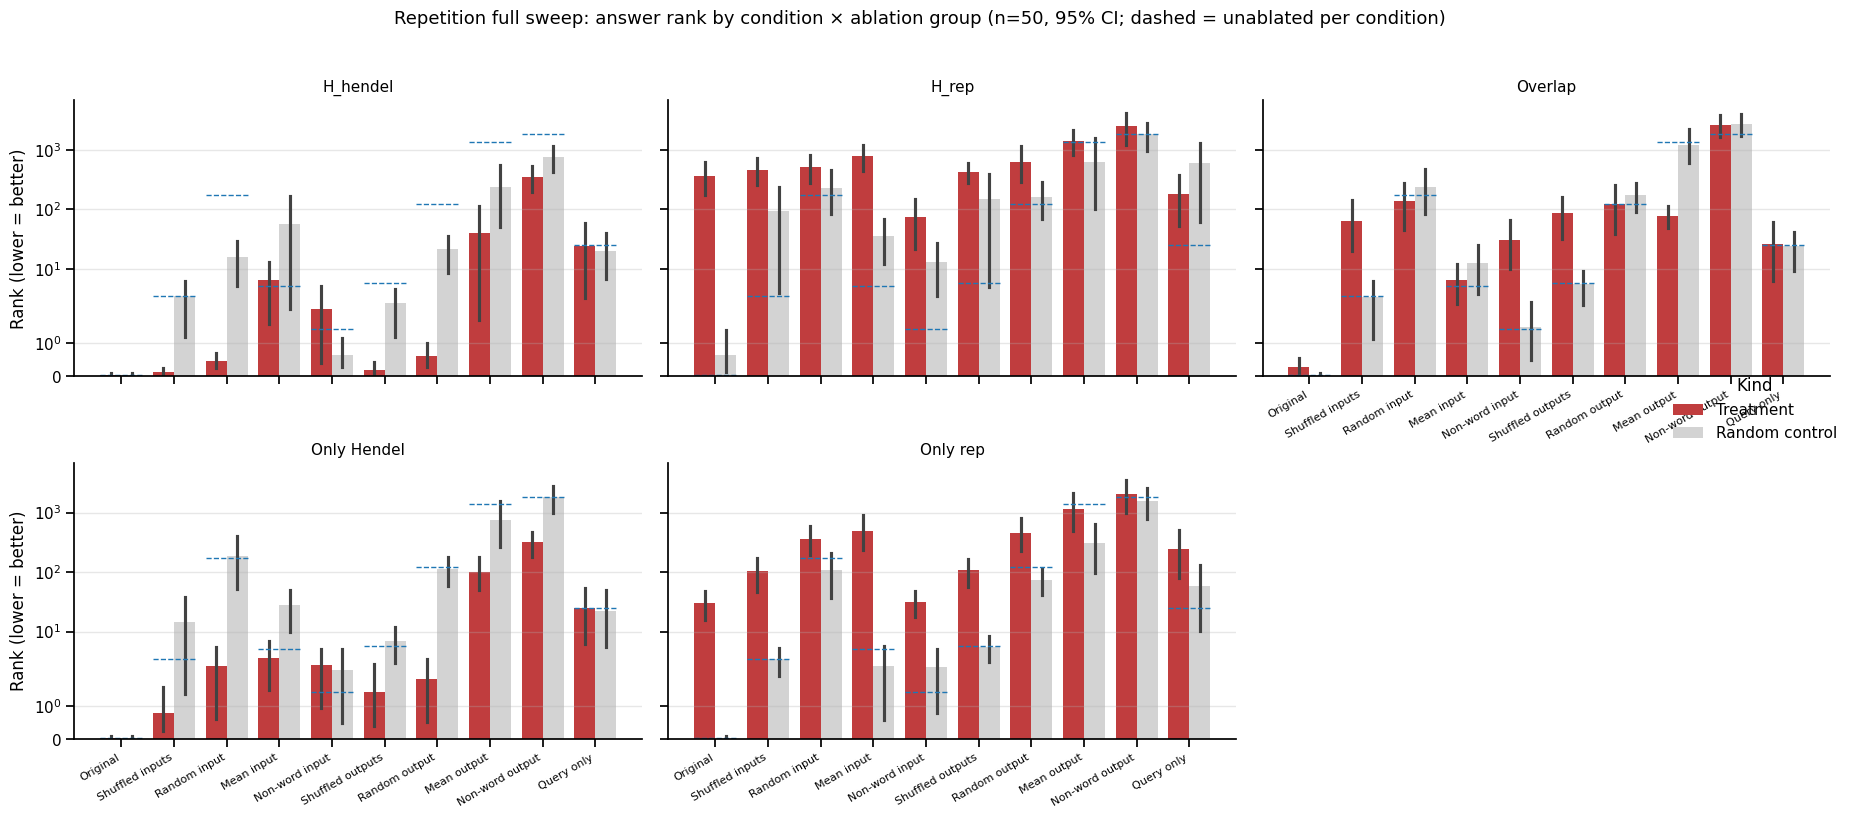

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

tick_map = {
    'orig':              'Original',
    'shuffled_inputs':   'Shuffled inputs',
    'random_inputs':     'Random input',
    'mean_embed_inputs': 'Mean input',
    'star_inputs':       'Non-word input',
    'query_only':        'Query only',
    'shuffled_outputs':  'Shuffled outputs',
    'random_outputs':    'Random output',
    'mean_embed_outputs':'Mean output',
    'star_outputs':      'Non-word output',
}
order_lab = [tick_map[c] for c in REP_CONDS]

PAIRS = [
    ('all_hendel',  'rand_for_hendel',  'H_hendel'),
    ('all_rep',     'rand_for_rep',     'H_rep'),
    ('overlap',     'rand_for_overlap', 'Overlap'),
    ('only_hendel', 'rand_for_only_h',  'Only Hendel'),
    ('only_rep',    'rand_for_only_r',  'Only rep'),
]

# Build long-form df: one row per (prompt, group, kind, condition)
def build_long(data_dict):
    rows = []
    for treat_key, ctrl_key, group_name in PAIRS:
        for c in REP_CONDS:
            for v in data_dict[treat_key][c]:
                rows.append({'Condition': tick_map[c], 'Group': group_name,
                             'Kind': 'Treatment', 'value': v})
            for v in data_dict[ctrl_key][c]:
                rows.append({'Condition': tick_map[c], 'Group': group_name,
                             'Kind': 'Random control', 'value': v})
    return pd.DataFrame(rows)

# Use FacetGrid over Group, with x=Condition, hue=Kind
def faceted_sweep(data_dict, n, title, ylabel, ylim=None, log=False):
    df = build_long(data_dict)
    g = sns.catplot(data=df, x='Condition', y='value', hue='Kind', col='Group',
                    order=order_lab, hue_order=['Treatment', 'Random control'],
                    palette={'Treatment': 'tab:red', 'Random control': 'lightgray'},
                    kind='bar', errorbar=('ci', 95), col_wrap=3, height=4, aspect=1.4,
                    sharey=True, legend_out=True)
    
    unab_means = {c: data_dict['unablated'][c].mean() for c in REP_CONDS}
    
    for ax, group_name in zip(g.axes.flat, [p[2] for p in PAIRS]):
        # Add unablated as small black tick per condition
        for x_pos, c in enumerate(REP_CONDS):
            ax.plot([x_pos - 0.4, x_pos + 0.4], [unab_means[c]] * 2,
                    color='tab:blue', linestyle='--', linewidth=1)
        ax.set_title(group_name, fontsize=11)
        if ylim: ax.set_ylim(*ylim)
        if log: ax.set_yscale('symlog')
        ax.grid(True, alpha=0.3, axis='y')
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
        ax.set_xlabel('')
        ax.set_ylabel(ylabel)
    
    g.figure.suptitle(f'{title} (n={n}, 95% CI; dashed = unablated per condition)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    return g

# Accuracy
faceted_sweep(rep_full_correct, n_rep_full,
              'Repetition full sweep: ICL accuracy by condition × ablation group',
              'Accuracy', ylim=(0, 1.0))

# Rank
faceted_sweep(rep_full_rank, n_rep_full,
              'Repetition full sweep: answer rank by condition × ablation group',
              'Rank (lower = better)', log=True)

## Full-sweep plots

NameError: name 'n_hendel_full' is not defined

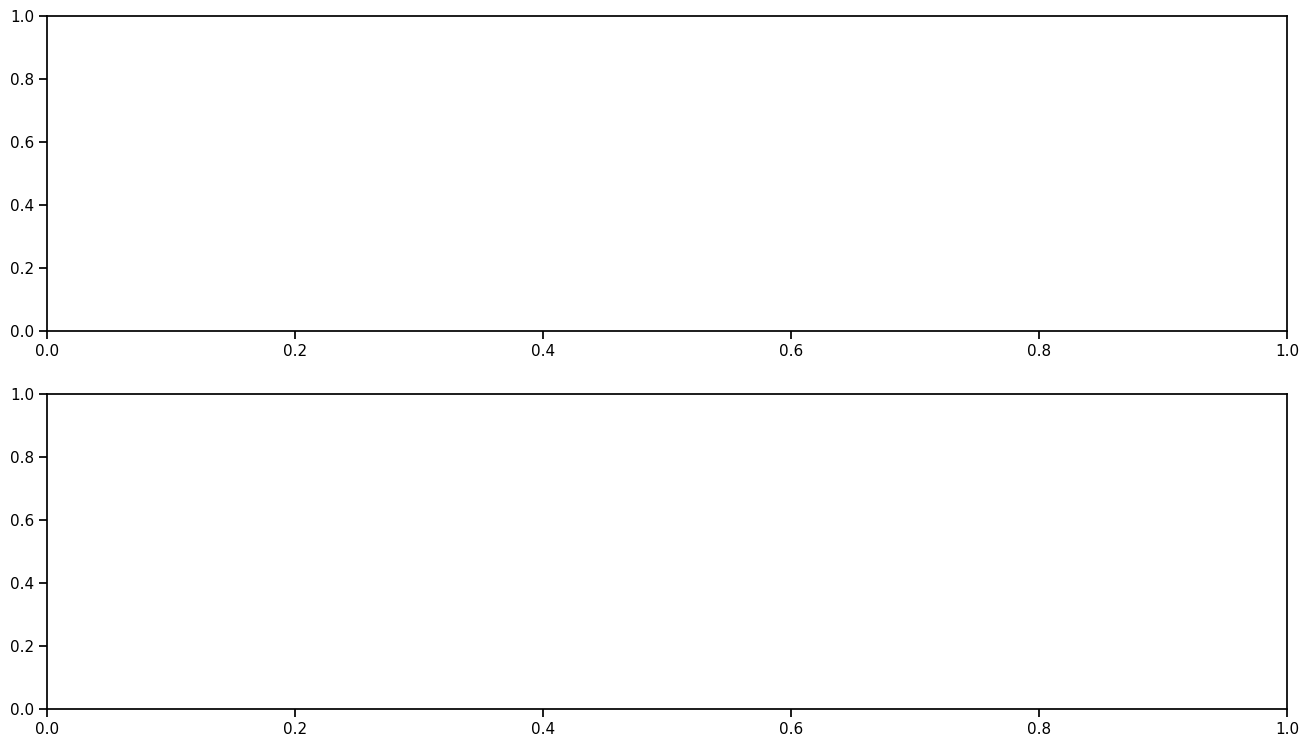

In [21]:
tick_map = {
    'orig':                     'Original',
    'shuffled':                 'Shuffled inputs',
    'shuffled_inputs':          'Shuffled inputs',
    'wrong_task_inputs':        'Wrong-task input',
    'random_from_input_pool':   'Random input',
    'random_inputs':            'Random input',
    'mean_embed_inputs':        'Mean input',
    'star_inputs':              'Non-word input',
    'query_only':               'Query only',
    'shuffled_outputs':         'Shuffled outputs',
    'wrong_task_outputs':       'Wrong-task output',
    'random_from_output_pool':  'Random output',
    'random_outputs':           'Random output',
    'mean_embed_outputs':       'Mean output',
    'star_outputs':             'Non-word output',
}

def sweep_plot(correct_dict, conds, n, title, ax):
    rows = []
    for ab in ABL_KEYS:
        for c in conds:
            for v in correct_dict[ab][c]:
                rows.append({'Condition': tick_map[c], 'Ablation': ab_label[ab], 'value': v})
    df = pd.DataFrame(rows)
    order_lab = [tick_map[c] for c in conds]
    sns.barplot(data=df, x='Condition', y='value', hue='Ablation',
                order=order_lab, hue_order=ab_order, palette=ab_palette,
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylabel('Accuracy'); ax.set_xlabel('')
    ax.set_ylim(0, 1.0)
    ax.set_title(f'{title} (n={n}, 95% CI)')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.legend(fontsize=8, loc='upper right')

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
sweep_plot(hendel_full_correct, HENDEL_CONDS, n_hendel_full,
           'Hendel: ICL accuracy by condition x ablation', axes[0])
sweep_plot(rep_full_correct, REP_CONDS, n_rep_full,
           'Repetition: ICL accuracy by condition x ablation', axes[1])
plt.tight_layout(); plt.show()

In [ ]:
def sweep_rank_plot(rank_dict, conds, n, title, ax):
    rows = []
    for ab in ABL_KEYS:
        for c in conds:
            for v in rank_dict[ab][c]:
                rows.append({'Condition': tick_map[c], 'Ablation': ab_label[ab], 'value': v})
    df = pd.DataFrame(rows)
    order_lab = [tick_map[c] for c in conds]
    sns.barplot(data=df, x='Condition', y='value', hue='Ablation',
                order=order_lab, hue_order=ab_order, palette=ab_palette,
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylabel('Rank (lower = better)'); ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.set_title(f'{title} (n={n}, 95% CI)')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.legend(fontsize=8, loc='upper left')

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
sweep_rank_plot(hendel_full_rank, HENDEL_CONDS, n_hendel_full,
                'Hendel: answer rank by condition x ablation', axes[0])
sweep_rank_plot(rep_full_rank, REP_CONDS, n_rep_full,
                'Repetition: answer rank by condition x ablation', axes[1])
plt.tight_layout(); plt.show()